# 02 — Temporal prevalence of detector-positive abstracts

In [2]:
from pathlib import Path
import zlib

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    from IPython.display import display
except ImportError:
    def display(value):
        if hasattr(value, "to_string"):
            print(value.to_string(index=False))
        else:
            print(value)
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, MultipleLocator, PercentFormatter

YEARS = list(range(2020, 2026))
DETECTOR_POSITIVE_DECISION = 0
N_BOOTSTRAP = 10_000
BOOTSTRAP_SEED = 20260722

search_roots = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next(
    (
        path
        for path in search_roots
        if (path / "data/processed/id_papers.csv").exists()
    ),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not locate data/processed/id_papers.csv from the current "
        f"working directory: {Path.cwd()}"
    )

INPUT_CSV = REPO_ROOT / "data/processed/id_papers.csv"
SOURCE_DATA_DIR = REPO_ROOT / "data/source_data/02_prevalence_trends"
SOURCE_DATA_DIR.mkdir(parents=True, exist_ok=True)

OVERALL_SOURCE_CSV = SOURCE_DATA_DIR / "annual_detector_positive_prevalence.csv"
CONFERENCE_SOURCE_CSV = (
    SOURCE_DATA_DIR / "conference_year_detector_positive_prevalence.csv"
)

print(f"Repository root: {REPO_ROOT}")
print(f"Input data: {INPUT_CSV}")
print(f"Source-data directory: {SOURCE_DATA_DIR}")
print(f"Bootstrap replicates: {N_BOOTSTRAP:,}")


Repository root: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub
Input data: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/processed/id_papers.csv
Source-data directory: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/02_prevalence_trends
Bootstrap replicates: 10,000


## Load and validate the processed analytical data

In [3]:
required_columns = {"id", "Conference", "Year", "finetuned_decision"}
papers = pd.read_csv(INPUT_CSV, encoding="utf-8-sig", low_memory=False)
missing_columns = sorted(required_columns.difference(papers.columns))
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

papers = papers.copy()
papers["Conference"] = papers["Conference"].astype("string").str.strip().str.upper()
papers["Year"] = pd.to_numeric(papers["Year"], errors="coerce")
papers["finetuned_decision"] = pd.to_numeric(
    papers["finetuned_decision"], errors="coerce"
)

in_period = papers["Year"].isin(YEARS)
invalid_in_period = papers[
    in_period
    & (
        papers["id"].isna()
        | papers["id"].astype(str).str.strip().eq("")
        | papers["Conference"].isna()
        | papers["Conference"].eq("")
        | ~papers["finetuned_decision"].isin([0, 1])
    )
]
if not invalid_in_period.empty:
    raise ValueError(
        f"Found {len(invalid_in_period):,} records with an invalid ID, "
        "conference, or finetuned_decision in 2020–2025"
    )

papers = papers[in_period].copy()
papers["Year"] = papers["Year"].astype(int)
duplicated = papers.duplicated("id", keep=False)
if duplicated.any():
    examples = papers.loc[duplicated, ["id", "Conference", "Year"]].head()
    raise ValueError(f"Paper IDs must be unique:\n{examples}")

papers["detector_positive"] = papers["finetuned_decision"].eq(
    DETECTOR_POSITIVE_DECISION
).astype(np.int8)

preferred_conferences = [
    "AAAI", "ACL", "CVPR", "EMNLP", "ICLR",
    "ICML", "IJCAI", "KDD", "SIGIR", "WWW",
]
observed_conferences = sorted(papers["Conference"].dropna().unique())
unexpected = sorted(set(observed_conferences) - set(preferred_conferences))
missing_expected = sorted(set(preferred_conferences) - set(observed_conferences))
if unexpected or missing_expected:
    raise ValueError(
        f"Conference mismatch; unexpected={unexpected}, missing={missing_expected}"
    )

print(f"Loaded {len(papers):,} unique papers")
print(f"Detector-positive abstracts: {papers['detector_positive'].sum():,}")
print(f"Conferences: {', '.join(preferred_conferences)}")
display(
    papers.groupby("Year", as_index=False)
    .agg(
        n_papers=("id", "size"),
        n_detector_positive=("detector_positive", "sum"),
    )
)

Loaded 91,856 unique papers
Detector-positive abstracts: 19,934
Conferences: AAAI, ACL, CVPR, EMNLP, ICLR, ICML, IJCAI, KDD, SIGIR, WWW


,Year,n_papers,n_detector_positive
0,2020,10030,146
1,2021,10983,172
2,2022,11749,178
3,2023,15724,1044
4,2024,18789,5336
5,2025,24581,13058


## Bootstrap helper

In [9]:
def bootstrap_binary_rate_ci(
    values: np.ndarray,
    *,
    seed: int,
    n_bootstrap: int = N_BOOTSTRAP,
) -> tuple[float, float, float]:
    binary = np.asarray(values, dtype=np.int8)
    if binary.size == 0:
        return np.nan, np.nan, np.nan

    observed_rate = float(binary.mean())
    rng = np.random.default_rng(seed)
    bootstrap_positive_counts = rng.binomial(
        n=binary.size,
        p=observed_rate,
        size=n_bootstrap,
    )
    bootstrap_rates = bootstrap_positive_counts / binary.size
    lower, upper = np.percentile(bootstrap_rates, [2.5, 97.5])
    return observed_rate, float(lower), float(upper)



## Overall annual prevalence: construct and save source data

In [5]:
annual_rows = []
for year in YEARS:
    annual_group = papers[papers["Year"].eq(year)]
    values = annual_group["detector_positive"].to_numpy(dtype=np.int8)
    if values.size == 0:
        raise ValueError(f"No observations for {year}")

    rate, lower, upper = bootstrap_binary_rate_ci(
        values,
        seed=BOOTSTRAP_SEED + year,
    )
    n_detector_positive = int(values.sum())
    annual_rows.append(
        {
            "year": year,
            "n_papers": int(values.size),
            "n_detector_positive": n_detector_positive,
            "n_detector_negative": int(values.size - n_detector_positive),
            "detector_positive_rate": rate,
            "bootstrap_ci_lower": lower,
            "bootstrap_ci_upper": upper,
            "detector_positive_rate_percent": 100.0 * rate,
            "bootstrap_ci_lower_percent": 100.0 * lower,
            "bootstrap_ci_upper_percent": 100.0 * upper,
            "n_bootstrap": N_BOOTSTRAP,
        }
    )

annual_prevalence = pd.DataFrame(annual_rows)
annual_prevalence.to_csv(
    OVERALL_SOURCE_CSV,
    index=False,
    encoding="utf-8-sig",
)

print(f"Saved overall source data: {OVERALL_SOURCE_CSV}")
display(annual_prevalence)

Saved overall source data: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/02_prevalence_trends/annual_detector_positive_prevalence.csv


,year,n_papers,n_detector_positive,n_detector_negative,detector_positive_rate,bootstrap_ci_lower,bootstrap_ci_upper,detector_positive_rate_percent,bootstrap_ci_lower_percent,bootstrap_ci_upper_percent,n_bootstrap
0,2020,10030,146,9884,0.014556,0.012263,0.016949,1.455633,1.226321,1.694915,10000
1,2021,10983,172,10811,0.015661,0.013384,0.017937,1.566057,1.338432,1.793681,10000
2,2022,11749,178,11571,0.015150,0.013022,0.017363,1.515023,1.302238,1.736318,10000
3,2023,15724,1044,14680,0.066395,0.062643,0.070338,6.639532,6.264309,7.033834,10000
4,2024,18789,5336,13453,0.283996,0.277503,0.290542,28.399596,27.750279,29.054234,10000
5,2025,24581,13058,11523,0.531223,0.524998,0.537488,53.122330,52.499797,53.748830,10000


## Overall annual prevalence: display figure


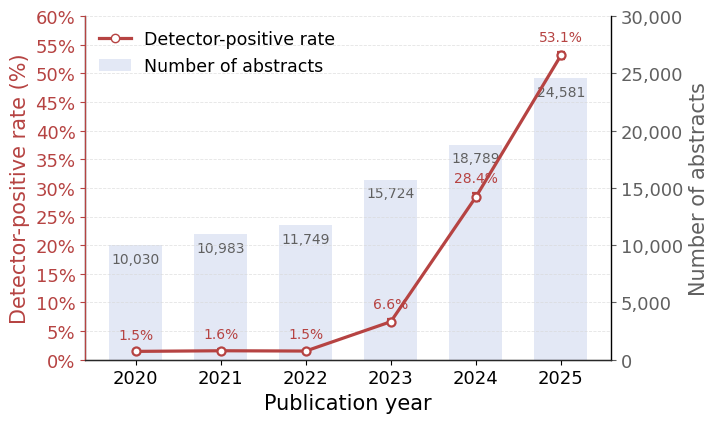

Displayed overall annual prevalence from: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/02_prevalence_trends/annual_detector_positive_prevalence.csv


In [6]:
mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans", "Liberation Sans"],
        "font.size": 14,
        "axes.labelsize": 15,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "axes.linewidth": 0.9,
        "legend.fontsize": 12.5,
        "legend.frameon": False,
        "figure.facecolor": "white",
    }
)

BAR_COLOR = "#E3E8F5"
COUNT_TEXT_COLOR = "#606060"
LINE_COLOR = "#B64342"
TEXT_COLOR = "#272727"
GRID_COLOR = "#D8D8D8"

annual_plot_data = pd.read_csv(OVERALL_SOURCE_CSV, encoding="utf-8-sig")
years = annual_plot_data["year"].to_numpy(dtype=int)
paper_counts = annual_plot_data["n_papers"].to_numpy(dtype=int)
rates = annual_plot_data["detector_positive_rate_percent"].to_numpy(float)
lower = annual_plot_data["bootstrap_ci_lower_percent"].to_numpy(float)
upper = annual_plot_data["bootstrap_ci_upper_percent"].to_numpy(float)
x = np.arange(len(years))

fig, ax_rate = plt.subplots(figsize=(7.3, 4.35))
ax_count = ax_rate.twinx()
bars = ax_count.bar(
    x,
    paper_counts,
    width=0.62,
    color=BAR_COLOR,
    edgecolor="none",
    linewidth=0,
    zorder=1,
)

ax_rate.errorbar(
    x,
    rates,
    yerr=np.vstack([rates - lower, upper - rates]),
    color=LINE_COLOR,
    linewidth=2.3,
    marker="o",
    markersize=5.8,
    markerfacecolor="white",
    markeredgecolor=LINE_COLOR,
    markeredgewidth=1.6,
    ecolor=LINE_COLOR,
    elinewidth=1.2,
    capsize=3.2,
    capthick=1.2,
    zorder=5,
)
ax_rate.set_zorder(ax_count.get_zorder() + 1)
ax_rate.patch.set_visible(False)

count_upper = int(np.ceil(paper_counts.max() * 1.18 / 5000.0) * 5000)
rate_upper = max(5.0, np.ceil((upper.max() + 2.0) / 5.0) * 5.0)
ax_count.set_ylim(0, count_upper)
ax_rate.set_ylim(0, rate_upper)
ax_rate.set_xticks(x, years)
ax_rate.set_xlabel("Publication year")
ax_rate.set_ylabel("Detector-positive rate (%)", color=LINE_COLOR)
ax_count.set_ylabel("Number of abstracts", color=COUNT_TEXT_COLOR)
ax_rate.tick_params(axis="y", colors=LINE_COLOR)
ax_count.tick_params(axis="y", colors=COUNT_TEXT_COLOR)
ax_count.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{int(value):,}")
)
ax_rate.yaxis.set_major_locator(MultipleLocator(5))
ax_rate.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax_rate.grid(
    axis="y",
    color=GRID_COLOR,
    linewidth=0.6,
    linestyle="--",
    alpha=0.7,
)
ax_rate.set_axisbelow(True)
ax_count.spines["top"].set_visible(False)
ax_rate.spines["top"].set_visible(False)
ax_rate.spines["left"].set_color(LINE_COLOR)
ax_count.spines["right"].set_color(COUNT_TEXT_COLOR)
ax_rate.spines["bottom"].set_color(TEXT_COLOR)

bar_label_offset = 0.020 * count_upper
rate_label_offset = 0.024 * rate_upper
for bar, count, ci_upper_value in zip(bars, paper_counts, upper):
    count_y = count - bar_label_offset
    count_va = "top"
    count_fraction = count_y / count_upper
    rate_label_fraction = (ci_upper_value + rate_label_offset) / rate_upper
    if abs(count_fraction - rate_label_fraction) < 0.06:
        count_y = count + 0.015 * count_upper
        count_va = "bottom"
    ax_count.text(
        bar.get_x() + bar.get_width() / 2,
        count_y,
        f"{count:,}",
        ha="center",
        va=count_va,
        fontsize=10.0,
        color=COUNT_TEXT_COLOR,
        zorder=3,
    )

for x_value, rate, ci_upper_value in zip(x, rates, upper):
    ax_rate.text(
        x_value,
        ci_upper_value + rate_label_offset,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10.0,
        color=LINE_COLOR,
        zorder=6,
    )

ax_rate.legend(
    handles=[
        Line2D(
            [0], [0], color=LINE_COLOR, linewidth=2.3, marker="o",
            markerfacecolor="white", markeredgecolor=LINE_COLOR,
            label="Detector-positive rate",
        ),
        Patch(
            facecolor=BAR_COLOR,
            edgecolor="none",
            label="Number of abstracts",
        ),
    ],
    loc="upper left",
    bbox_to_anchor=(0.0, 1.0),
    ncol=1,
    handlelength=1.8,
    borderaxespad=0.4,
)
fig.tight_layout(pad=0.8)
plt.show()
print(f"Displayed overall annual prevalence from: {OVERALL_SOURCE_CSV}")

## Conference-year prevalence: construct and save source data


In [7]:
conference_year_rows = []
for conference in preferred_conferences:
    for year in YEARS:
        group = papers[
            papers["Conference"].eq(conference)
            & papers["Year"].eq(year)
        ]
        values = group["detector_positive"].to_numpy(dtype=np.int8)
        if values.size == 0:
            raise ValueError(f"Empty conference-year cell: {conference}, {year}")

        stable_conference_seed = zlib.crc32(conference.encode("utf-8"))
        rate, lower, upper = bootstrap_binary_rate_ci(
            values,
            seed=BOOTSTRAP_SEED + stable_conference_seed + year,
        )
        n_detector_positive = int(values.sum())
        conference_year_rows.append(
            {
                "conference": conference,
                "year": year,
                "n_papers": int(values.size),
                "n_detector_positive": n_detector_positive,
                "n_detector_negative": int(values.size - n_detector_positive),
                "detector_positive_rate": rate,
                "bootstrap_ci_lower": lower,
                "bootstrap_ci_upper": upper,
                "detector_positive_rate_percent": 100.0 * rate,
                "bootstrap_ci_lower_percent": 100.0 * lower,
                "bootstrap_ci_upper_percent": 100.0 * upper,
                "n_bootstrap": N_BOOTSTRAP,
            }
        )

conference_prevalence = pd.DataFrame(conference_year_rows)
conference_prevalence.to_csv(
    CONFERENCE_SOURCE_CSV,
    index=False,
    encoding="utf-8-sig",
)

print(f"Saved conference-year source data: {CONFERENCE_SOURCE_CSV}")
display(conference_prevalence)

Saved conference-year source data: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/02_prevalence_trends/conference_year_detector_positive_prevalence.csv


,conference,year,n_papers,n_detector_positive,n_detector_negative,detector_positive_rate,bootstrap_ci_lower,bootstrap_ci_upper,detector_positive_rate_percent,bootstrap_ci_lower_percent,bootstrap_ci_upper_percent,n_bootstrap
0,AAAI,2020,1902,22,1880,0.011567,0.006835,0.016824,1.156677,0.683491,1.682440,10000
1,AAAI,2021,2058,39,2019,0.018950,0.013120,0.025267,1.895044,1.311953,2.526725,10000
2,AAAI,2022,1679,24,1655,0.014294,0.008934,0.020250,1.429422,0.893389,2.025015,10000
3,AAAI,2023,2076,46,2030,0.022158,0.015896,0.028420,2.215800,1.589595,2.842004,10000
4,AAAI,2024,2881,675,2206,0.234294,0.218674,0.249913,23.429365,21.867407,24.991322,10000
5,AAAI,2025,3508,1592,1916,0.453820,0.437001,0.470068,45.381984,43.700114,47.006842,10000
6,ACL,2020,887,14,873,0.015784,0.007892,0.024803,1.578354,0.789177,2.480271,10000
7,ACL,2021,1246,20,1226,0.016051,0.009631,0.023274,1.605136,0.963082,2.327448,10000
8,ACL,2022,1105,20,1085,0.018100,0.010860,0.026244,1.809955,1.085973,2.624434,10000
9,ACL,2023,2148,116,2032,0.054004,0.044693,0.063780,5.400372,4.469274,6.378026,10000


## Conference-year prevalence: display figure

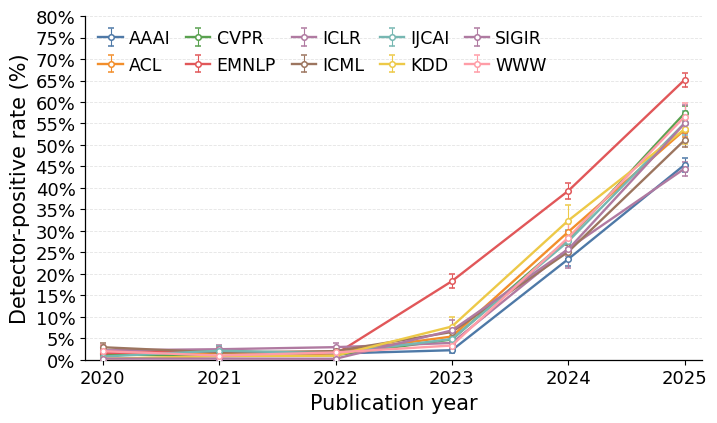

Displayed conference-year prevalence from: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/02_prevalence_trends/conference_year_detector_positive_prevalence.csv


In [8]:
conference_plot_data = pd.read_csv(
    CONFERENCE_SOURCE_CSV, encoding="utf-8-sig"
)
conference_colors = {
    "AAAI": "#4E79A7",
    "ACL": "#F28E2B",
    "CVPR": "#59A14F",
    "EMNLP": "#E15759",
    "ICLR": "#B07AA1",
    "ICML": "#9C755F",
    "IJCAI": "#76B7B2",
    "KDD": "#EDC948",
    "SIGIR": "#AF7AA1",
    "WWW": "#FF9DA7",
}

fig, ax = plt.subplots(figsize=(7.3, 4.35))
maximum_ci = conference_plot_data["bootstrap_ci_upper_percent"].max()
rate_upper = max(10.0, np.ceil((maximum_ci + 10.0) / 5.0) * 5.0)

for conference in preferred_conferences:
    data = conference_plot_data[
        conference_plot_data["conference"].eq(conference)
    ].sort_values("year")
    years = data["year"].to_numpy(dtype=int)
    rates = data["detector_positive_rate_percent"].to_numpy(float)
    lower = data["bootstrap_ci_lower_percent"].to_numpy(float)
    upper = data["bootstrap_ci_upper_percent"].to_numpy(float)
    color = conference_colors[conference]
    ax.errorbar(
        years,
        rates,
        yerr=np.vstack([rates - lower, upper - rates]),
        color=color,
        ecolor=color,
        linewidth=1.7,
        elinewidth=0.8,
        capsize=2.0,
        capthick=0.8,
        marker="o",
        markersize=4.0,
        markerfacecolor="white",
        markeredgecolor=color,
        markeredgewidth=1.1,
        label=conference,
        zorder=3,
    )

ax.set_xlim(min(YEARS) - 0.15, max(YEARS) + 0.15)
ax.set_ylim(0, rate_upper)
ax.set_xticks(YEARS)
ax.set_xlabel("Publication year")
ax.set_ylabel("Detector-positive rate (%)")
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.grid(
    axis="y",
    color=GRID_COLOR,
    linewidth=0.6,
    linestyle="--",
    alpha=0.7,
)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.0, 1.0),
    ncol=5,
    columnspacing=0.9,
    handlelength=1.4,
    handletextpad=0.35,
    borderaxespad=0.35,
    fontsize=12.5,
)
fig.tight_layout(pad=0.8)
plt.show()
print(f"Displayed conference-year prevalence from: {CONFERENCE_SOURCE_CSV}")